<a href="https://colab.research.google.com/github/ashutosh-kedar/food_not_food_distil_bert_uncase_fine_tuned/blob/main/Finetuned_DistilBert_Food_Not_Food_Classification_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing modules

In [2]:
try:
  import transformers
  import datasets
  import evaluate
except ModuleNotFoundError:
  !pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [3]:
HUGGING_FACE_DATASET_PATH = 'ashutosh-kedar/food_not_food_synthetic_dataset'
HUGGING_FACE_DISTIL_BERT_UNCASE = 'distilbert/distilbert-base-uncased'
MODEL_OUTPUT_DIR = 'models/finetuned_distil_bert_food_not_food_classification_model'

### Getting food not food dataset

In [4]:
dataset_dict = datasets.load_dataset(HUGGING_FACE_DATASET_PATH)
dataset = dataset_dict.get('train')
dataset

README.md:   0%|          | 0.00/3.58k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/250 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 250
})

In [5]:
import random

view_count = 4

def print_random_data_from_dataset(dataset,count):
  for _ in range(count):
    random_idx = random.randint(0,len(dataset))
    record = dataset[random_idx]
    print(record.get('text'),'->',record.get('label'))

print_random_data_from_dataset(dataset,view_count)

Two people sitting at a dining room table with a newspaper on it -> not_food
Pizza with a dessert twist, featuring a sweet Nutella base and fresh strawberries on top -> food
Sushi platter showcasing a variety of colorful rolls and garnishes. -> food
Hammock swaying between two trees -> not_food


In [6]:
labels = dataset_dict.get('train').unique('label')[::-1]

In [7]:
label2id = {label:id for id,label in enumerate(labels)}
id2label = {id:label for id,label in enumerate(labels)}
label2id,id2label

({'food': 0, 'not_food': 1}, {0: 'food', 1: 'not_food'})

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path =HUGGING_FACE_DISTIL_BERT_UNCASE,
    use_fast=True
)
tokenizer

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertTokenizer(name_or_path='distilbert/distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [9]:
def transform_data(record):
  record['label'] =  label2id.get(record['label'])
  return tokenizer(
      text=record.get('text'),
      padding=True,
      truncate=True
  )

In [10]:
dataset = dataset_dict.get('train').map(transform_data)

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

In [11]:
dataset[0]

{'text': 'Set of test tubes arranged in a rack',
 'label': 1,
 'input_ids': [101, 2275, 1997, 3231, 10868, 5412, 1999, 1037, 14513, 102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [12]:
dataset_dict = dataset.train_test_split(test_size=0.2)
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50
    })
})

In [36]:
import evaluate
import torch
import numpy as np

accuracy_fn = evaluate.load('accuracy')

def get_accuracy(data):
  predictions,actual = data
  predictions = np.argmax(predictions,axis=1)
  # predictions = torch.argmax(torch.softmax(torch.tensor(predictions),dim=1),dim=1)
  # print('data',type(predictions),type(actual))
  # print('data',predictions,actual)

  return accuracy_fn.compute(predictions=predictions,references=actual)

In [39]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir = MODEL_OUTPUT_DIR,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=0.0001,
    save_total_limit=3,
    seed=42,
    load_best_model_at_end=True,
    push_to_hub=False,
    num_train_epochs=10
)

In [40]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path=HUGGING_FACE_DISTIL_BERT_UNCASE,
    num_labels = 2,
    label2id=label2id,
    id2label=id2label
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [41]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict.get('train'),
    eval_dataset=dataset_dict.get('test'),
    processing_class=tokenizer,
    compute_metrics=get_accuracy
)


In [42]:
training_results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.467415,0.207603,1.000000
2,0.123666,0.015144,1.000000
3,0.010516,0.020216,0.980000
4,0.002609,0.002443,1.000000
5,0.001349,0.000831,1.000000
6,0.000870,0.000622,1.000000
7,0.000719,0.000528,1.000000
8,0.000635,0.000479,1.000000
9,0.000609,0.000455,1.000000
10,0.000583,0.000447,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [43]:
training_results.metrics

{'train_runtime': 221.2518,
 'train_samples_per_second': 9.039,
 'train_steps_per_second': 0.316,
 'total_flos': 17297344540128.0,
 'train_loss': 0.06089704652716007,
 'epoch': 10.0}

In [46]:
log_history = trainer.state.log_history
final_result = log_history[-1]
final_result

{'train_runtime': 221.2518,
 'train_samples_per_second': 9.039,
 'train_steps_per_second': 0.316,
 'total_flos': 17297344540128.0,
 'train_loss': 0.06089704652716007,
 'epoch': 10.0,
 'step': 70}

In [47]:
training_log_history = log_history[0::2]
test_log_history = log_history[1::2]

In [49]:
import pandas as pd

training_log_history_df = pd.DataFrame(training_log_history)
test_log_history_df = pd.DataFrame(test_log_history)
test_log_history_df

,eval_loss,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,0.207603,1.00,0.0588,850.644,34.026,1.0,7
1,0.015144,1.00,0.0622,803.488,32.140,2.0,14
2,0.020216,0.98,0.0738,677.867,27.115,3.0,21
3,0.002443,1.00,0.0641,779.802,31.192,4.0,28
4,0.000831,1.00,0.0709,705.347,28.214,5.0,35
5,0.000622,1.00,0.0708,706.333,28.253,6.0,42
6,0.000528,1.00,0.0651,768.416,30.737,7.0,49
7,0.000479,1.00,0.0694,719.976,28.799,8.0,56
8,0.000455,1.00,0.0633,789.353,31.574,9.0,63
9,0.000447,1.00,0.0627,797.645,31.906,10.0,70


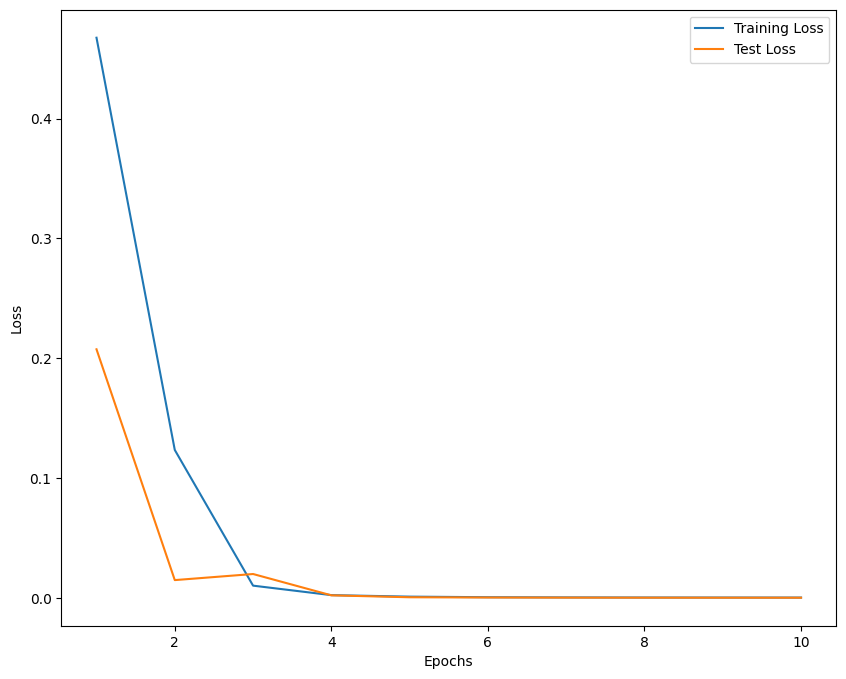

In [50]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,8))
plt.plot(training_log_history_df['epoch'],training_log_history_df['loss'],label='Training Loss')
plt.plot(test_log_history_df['epoch'],test_log_history_df['eval_loss'],label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


###Saving the model to the local directory

In [51]:
trainer.save_model(output_dir=MODEL_OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

###Pushing fine tuned model to hugging face

In [52]:
trainer.push_to_hub(commit_message='Fine Tuned Distil Bert on Food Not Food Dataset')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...n_model/model.safetensors:   6%|6         | 16.4MB /  268MB            

  ...n_model/training_args.bin:   2%|1         |  87.0B / 5.20kB            

CommitInfo(commit_url='https://huggingface.co/ashutosh-kedar/finetuned_distil_bert_food_not_food_classification_model/commit/6f5900569f0aca67ff009c1caabcfc3e52815e6f', commit_message='Fine Tuned Distil Bert on Food Not Food Dataset', commit_description='', oid='6f5900569f0aca67ff009c1caabcfc3e52815e6f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ashutosh-kedar/finetuned_distil_bert_food_not_food_classification_model', endpoint='https://huggingface.co', repo_type='model', repo_id='ashutosh-kedar/finetuned_distil_bert_food_not_food_classification_model'), pr_revision=None, pr_num=None)